# 2 — Running the model on *your* spectrum

Notebook 1 used a spectrum already on the model's wavelength grid. Yours will not be.

This notebook covers getting an arbitrary spectrum onto that grid, and — more importantly —
what the grid choice does to your emission lines.

## The model's grid

`specsr` works on a fixed logarithmic grid: constant resolving power `lambda/dlambda = 4000`,
6,671 samples from 1.0 to 5.3 um.

Logarithmic, not linear, for a specific reason: on a log grid a redshift is a *uniform shift*
along the axis. The model is convolutional, and convolutions are translation-equivariant, so the
same line looks like the same pattern at every redshift. On a linear grid it would not, and the
model would have to learn each redshift separately.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specsr.data.grid import DEFAULT_GRID

print(DEFAULT_GRID)
grid = DEFAULT_GRID.centers()
print(f"{grid.size} samples, {grid[0]:.3f}-{grid[-1]:.3f} um")
print(f"step at 2 um: {2.0/4000*1e4:.2f} A     step at 5 um: {5.0/4000*1e4:.2f} A")

LogWavelengthGrid(1.0-5.3 um, R=4000, N=6671)
6671 samples, 1.000-5.300 um
step at 2 um: 5.00 A     step at 5 um: 12.50 A


## Just pass your wavelengths

The pipeline resamples for you:

```python
result = pipeline(my_flux, my_wavelength)
```

That is the whole answer. The rest of this notebook is about *why* the pipeline resamples onto
a grid this fine, because that choice matters far more than it looks.

## Grid coarseness destroys emission lines

Flux density is an **area under the curve** — its integral over a wavelength range is the line
flux astronomers actually use.

If you resample onto a grid too coarse to sample your lines, that area is lost, and no choice
of interpolation method saves you. Here is the effect measured on the 24 sample galaxies:
integrated flux of each galaxy's brightest line, after moving to log grids of decreasing
resolving power.

In [2]:
from specsr.data.grid import resample_flux_conserving

trapz = getattr(np, "trapezoid", np.trapz)   # numpy renamed it in 2.0
data24 = np.load("sample_24_spectra.npz", allow_pickle=True)
wl = data24["wavelength"].astype(float)

def line_flux(w, f, lam0, half=0.006, off=0.020):
    """Continuum-subtracted integrated flux in a window around lam0."""
    sel  = np.abs(w - lam0) < half
    side = (np.abs(w - lam0) > off) & (np.abs(w - lam0) < off + 2 * half)
    return trapz(f[sel] - np.nanmedian(f[side]), w[sel])

rows = []
for N in (6671, 2500, 1200, 600):
    target = np.geomspace(1.0, 5.3, N)
    R = N / np.log(5.3 / 1.0)
    cons, lin = [], []
    for k in range(len(data24["flux_high"])):
        f = data24["flux_high"][k].astype(float)
        ok = np.isfinite(f)
        if ok.sum() < 500:
            continue
        lam0 = wl[int(np.nanargmax(np.where(ok, f, -np.inf)))]
        truth = line_flux(wl, f, lam0)
        if not np.isfinite(truth) or truth <= 0:
            continue
        cons.append(line_flux(target, resample_flux_conserving(wl, f, target), lam0) / truth)
        lin.append(line_flux(target, np.interp(target, wl, f), lam0) / truth)
    rows.append((N, R, np.median(cons), np.median(lin)))

print(f"{'samples':>8} {'R_grid':>7} | {'conserving':>11} {'np.interp':>10}")
for N, R, a, b in rows:
    print(f"{N:>8} {R:>7.0f} | {a:>11.3f} {b:>10.3f}")

 samples  R_grid |  conserving  np.interp
    6671    4000 |       1.000      1.000
    2500    1499 |       0.959      0.952
    1200     720 |       0.916      0.886
     600     360 |       0.549      0.618


Read the **rows**, not the columns. Going from R=4000 to R~360 costs roughly half of every
line's flux, while the two resampling methods stay within a few percent of each other until
the grid is already so coarse that both have lost most of the line. At that last row the
ordering even flips and interpolation scores higher — which is not a point in its favour, just
a sign that at R~360 neither method is measuring a line any more. **The grid does the damage,
not the interpolant.**

This is not hypothetical. An earlier version of this project resampled everything onto
`linspace(1, 5, 2500)`, which undersampled the gratings by up to 2.5x. It was destroying about
a fifth of every line peak before the model ever saw the data, and the loss was mistaken for a
limitation of the model for months.

**The practical rule:** never resample onto a grid coarser than the features you care about.
The pipeline's R=4000 grid is chosen to be finer than the native sampling of every JADES arm,
so passing `wavelength=` and letting it resample is safe.

## Why the default is still flux-conserving

Given the columns above barely differ, why not interpolate?

Because "barely differs" is a property of *this* grid, not a guarantee. Conservation is correct
by construction — `sum(flux x bin_width)` is preserved exactly — whereas interpolation happens
to be close when the grid is fine and drifts when it is not. When a method is correct at no
extra cost, use it.

In [3]:
f = data24["flux_high"][0].astype(float)
target = np.geomspace(1.0, 5.3, 1200)
ok = np.isfinite(f)
truth_total = trapz(f[ok], wl[ok])
c = resample_flux_conserving(wl, f, target)
i = np.interp(target, wl, f)
m = np.isfinite(c) & np.isfinite(i)
print(f"total integrated flux retained, conserving: {trapz(c[m], target[m])/truth_total:.5f}")
print(f"total integrated flux retained, np.interp : {trapz(i[m], target[m])/truth_total:.5f}")

total integrated flux retained, conserving: 1.00001
total integrated flux retained, np.interp : 0.99692


## End to end on an off-grid spectrum

The realistic case: a spectrum on its own linear grid, its own sampling, its own coverage.

In [4]:
from specsr.inference import SpecSRPipeline

pipeline = SpecSRPipeline.from_pretrained()
one = np.load("sample_one_spectrum.npz", allow_pickle=True)

# Pretend this came out of your own reduction.
my_wavelength = np.linspace(1.05, 5.1, 1800)
my_flux = resample_flux_conserving(wl, one["flux_low"].astype(float), my_wavelength)
print("my spectrum:", my_flux.shape, "on", my_wavelength.shape, "wavelengths -- not the model grid")

result = pipeline(my_flux, my_wavelength)

print("output:", result.sr2.shape, "on the model's grid")
print(f"predicted z = {result.z[0]:.4f} +/- {result.z_sigma[0]:.4f}   (true {float(one['z']):.4f})")

my spectrum: (1800,) on (1800,) wavelengths -- not the model grid


output: (1, 6671) on the model's grid
predicted z = 2.5973 +/- 0.9959   (true 2.9985)


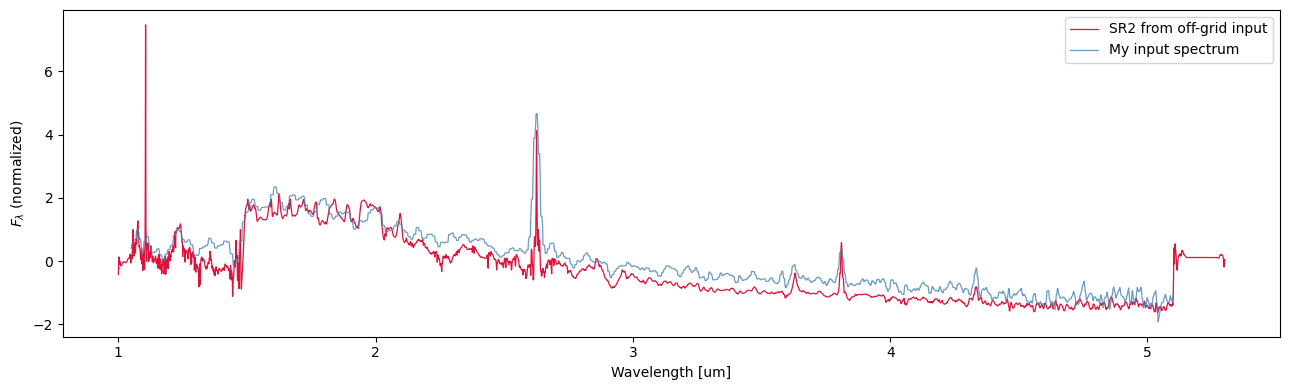

In [5]:
standardise = lambda x: (np.asarray(x, float) - np.nanmean(x)) / np.nanstd(x)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(result.wavelength, standardise(result.sr2[0]), lw=0.9, color="crimson",
        label="SR2 from off-grid input")
ax.plot(my_wavelength, standardise(my_flux), lw=0.9, color="steelblue", alpha=0.8,
        label="My input spectrum")
ax.set_xlabel("Wavelength [um]"); ax.set_ylabel(r"$F_\lambda$ (normalized)")
ax.legend(); fig.tight_layout()

## Coverage and gaps

Your spectrum will rarely span the full 1.0-5.3 um. Where it does not, the resampled input is
filled with `NaN`, which the pipeline standardises to zero before the model sees it.

The model still produces output across the whole grid. **Output outside your input's coverage
is extrapolation, not measurement.** Mask it:

In [6]:
covered = ((result.wavelength >= my_wavelength.min()) &
           (result.wavelength <= my_wavelength.max()))
print(f"{covered.sum()} of {covered.size} output samples are backed by input data "
      f"({covered.mean():.1%})")

sr2_masked = np.where(covered, result.sr2[0], np.nan)   # use this, not result.sr2[0]

6321 of 6671 output samples are backed by input data (94.8%)


## Units

The pipeline standardises internally and maps back onto the **input's** scale, so there is no
unit convention to match. But as notebook 1 showed, that scale is not the true high-resolution
spectrum's scale — compare shapes in normalized units.

The input must be **flux density**, not flux-per-pixel or counts, since flux-conserving
rebinning assumes the values are densities.

Next: **notebook 3** runs a batch and quantifies how far to trust the output.